# GDELT Sentiment — углублённый анализ\n\n**Эксперимент 1:** Эффект GDELT только для топ-игроков (больше упоминаний → меньше шума)  \n**Эксперимент 2:** Spike detection — резкие изменения тона вместо скользящих средних

In [1]:
import pandas as pd
import numpy as np
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, roc_auc_score
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# Загрузка данных
df = pd.read_csv("norm_dataframe.csv", index_col=0)
df['tourney_date'] = pd.to_datetime(df['tourney_date'])

gdelt = pd.read_csv("gdelt_google_api_cache.csv")
gdelt['date'] = pd.to_datetime(gdelt['date'])

print(f"Матчей: {len(df)}")
print(f"GDELT записей: {len(gdelt)}")
print(f"Уникальных игроков в GDELT: {gdelt['player_id'].nunique()}")
print(f"Период GDELT: {gdelt['date'].min().date()} — {gdelt['date'].max().date()}")
print(f"Период матчей: {df['tourney_date'].min().date()} — {df['tourney_date'].max().date()}")

Матчей: 95367
GDELT записей: 181046
Уникальных игроков в GDELT: 724
Период GDELT: 2016-07-17 — 2024-12-31
Период матчей: 1991-01-07 — 2024-12-18


## Определяем топ-игроков по количеству упоминаний в GDELT\n\nГипотеза: для малоизвестных игроков GDELT-данные слишком шумные (мало упоминаний, случайные совпадения имён). Для топ-игроков сигнал должен быть чище.

Топ-20 игроков по упоминаниям в GDELT:
           total_mentions  n_days  avg_daily_volume
player_id                                          
104925             193374    3070         62.988274
104745             146996    3065         47.959543
103819             139660    3079         45.358883
104918              93311    2986         31.249498
106421              51400    2050         25.073171
100644              48406    2459         19.685238
106401              47775    2380         20.073529
207989              41219    1188         34.696128
126774              38067    2048         18.587402
106233              34078    2144         15.894590
104527              30783    1939         15.875709
105449              26491    3002          8.824450
105777              26461    1986         13.323766
104731              26454    2774          9.536410
105227              26096    1671         15.616996
206173              25704    1281         20.065574
126094              24452

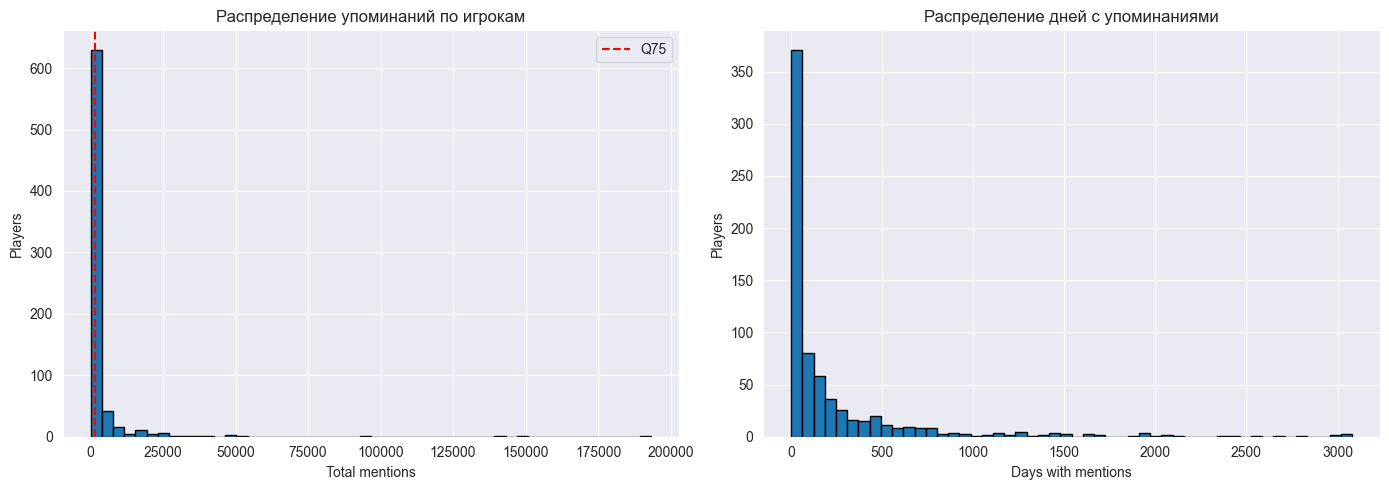


Порог для 'топ-игроков': >= 1411 упоминаний
Топ-игроков: 181


In [2]:
# Статистика покрытия GDELT по игрокам
player_gdelt_stats = gdelt.groupby('player_id').agg(
    total_mentions=('volume', 'sum'),
    n_days=('date', 'nunique'),
    avg_daily_volume=('volume', 'mean'),
).sort_values('total_mentions', ascending=False)

print("Топ-20 игроков по упоминаниям в GDELT:")
print(player_gdelt_stats.head(20))
print(f"\nМедиана упоминаний: {player_gdelt_stats['total_mentions'].median():.0f}")
print(f"Среднее упоминаний: {player_gdelt_stats['total_mentions'].mean():.0f}")

# Распределение
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].hist(player_gdelt_stats['total_mentions'], bins=50, edgecolor='black')
axes[0].set_xlabel('Total mentions')
axes[0].set_ylabel('Players')
axes[0].set_title('Распределение упоминаний по игрокам')
axes[0].axvline(player_gdelt_stats['total_mentions'].quantile(0.75), color='red', ls='--', label='Q75')
axes[0].legend()

axes[1].hist(player_gdelt_stats['n_days'], bins=50, edgecolor='black')
axes[1].set_xlabel('Days with mentions')
axes[1].set_ylabel('Players')
axes[1].set_title('Распределение дней с упоминаниями')
plt.tight_layout()
plt.show()

# Порог: топ-25% по количеству упоминаний
top_threshold = player_gdelt_stats['total_mentions'].quantile(0.75)
top_players = set(player_gdelt_stats[player_gdelt_stats['total_mentions'] >= top_threshold].index)
print(f"\nПорог для 'топ-игроков': >= {top_threshold:.0f} упоминаний")
print(f"Топ-игроков: {len(top_players)}")

## Генерация GDELT-фичей: MA + Spike Detection\n\nДля каждого игрока вычисляем:\n- **MA-фичи** (как раньше): скользящие средние тона и объёма за 5/10/20/50 дней\n- **Spike-фичи** (новые): z-score тона и объёма относительно скользящего окна — ловим резкие всплески/падения

In [3]:
def build_gdelt_features(gdelt_df):
    """Строит MA и spike-фичи для каждого игрока."""
    gdelt_sorted = gdelt_df.sort_values(['player_id', 'date'])
    
    all_features = []
    
    for pid, grp in gdelt_sorted.groupby('player_id'):
        # Reindex на полный дневной диапазон для корректных скользящих окон
        grp = grp.set_index('date').sort_index()
        idx = pd.date_range(grp.index.min(), grp.index.max(), freq='D')
        grp = grp.reindex(idx)
        grp['player_id'] = pid
        grp['volume'] = grp['volume'].fillna(0)
        grp['tone'] = grp['tone'].fillna(np.nan)  # NaN для дней без упоминаний
        # Forward-fill тона (последний известный тон)
        grp['tone'] = grp['tone'].ffill()
        
        # MA-фичи
        for w in [5, 10, 20, 50]:
            grp[f'tone_ma{w}'] = grp['tone'].rolling(w, min_periods=1).mean()
            grp[f'volume_ma{w}'] = grp['volume'].rolling(w, min_periods=1).mean()
        
        # Spike-фичи: z-score относительно 30-дневного окна
        for col in ['tone', 'volume']:
            rolling_mean = grp[col].rolling(30, min_periods=7).mean()
            rolling_std = grp[col].rolling(30, min_periods=7).std()
            grp[f'{col}_zscore'] = (grp[col] - rolling_mean) / rolling_std.replace(0, np.nan)
        
        # Spike: бинарный признак — z-score > 2 или < -2
        grp['tone_spike_pos'] = (grp['tone_zscore'] > 2).astype(float)
        grp['tone_spike_neg'] = (grp['tone_zscore'] < -2).astype(float)
        grp['volume_spike'] = (grp['volume_zscore'] > 2).astype(float)
        
        # Кумулятивный spike-счётчик за последние 7 дней
        grp['tone_spike_pos_7d'] = grp['tone_spike_pos'].rolling(7, min_periods=1).sum()
        grp['tone_spike_neg_7d'] = grp['tone_spike_neg'].rolling(7, min_periods=1).sum()
        grp['volume_spike_7d'] = grp['volume_spike'].rolling(7, min_periods=1).sum()
        
        # Изменение тона за последние 3 дня vs предыдущие 7 дней
        grp['tone_momentum'] = grp['tone'].rolling(3, min_periods=1).mean() - grp['tone'].rolling(10, min_periods=3).mean()
        
        grp = grp.reset_index().rename(columns={'index': 'date'})
        all_features.append(grp)
    
    return pd.concat(all_features, ignore_index=True)

gdelt_feat = build_gdelt_features(gdelt)
print(f"GDELT features shape: {gdelt_feat.shape}")
print(f"Колонки: {[c for c in gdelt_feat.columns if c not in ['date', 'player_id', 'player_name', 'volume', 'tone']]}")

GDELT features shape: (1592129, 22)
Колонки: ['tone_ma5', 'volume_ma5', 'tone_ma10', 'volume_ma10', 'tone_ma20', 'volume_ma20', 'tone_ma50', 'volume_ma50', 'tone_zscore', 'volume_zscore', 'tone_spike_pos', 'tone_spike_neg', 'volume_spike', 'tone_spike_pos_7d', 'tone_spike_neg_7d', 'volume_spike_7d', 'tone_momentum']


## Джойн GDELT-фичей с матчами\n\nДля каждого матча берём GDELT-фичи обоих игроков на дату матча и считаем разницу (PLAYER_1 - PLAYER_2).

In [4]:
feature_cols = [c for c in gdelt_feat.columns if c not in ['date', 'player_id', 'player_name', 'volume', 'tone']]

# asof merge: для каждого матча берём последние известные GDELT-фичи (на дату матча или раньше)
gdelt_feat_sorted = gdelt_feat.sort_values('date')

def merge_gdelt_for_player(matches, gdelt_features, player_col, suffix):
    """asof-merge GDELT фичей для одного игрока."""
    m = matches[['match_idx', 'tourney_date', player_col]].copy()
    m = m.rename(columns={player_col: 'player_id', 'tourney_date': 'date'}).sort_values('date')
    m['player_id'] = m['player_id'].astype(int)
    
    gf = gdelt_features[['date', 'player_id'] + feature_cols].copy()
    gf['player_id'] = gf['player_id'].astype(int)
    gf = gf.sort_values('date')
    
    merged = pd.merge_asof(
        m, gf,
        on='date',
        by='player_id',
        direction='backward'
    )
    merged = merged.set_index('match_idx')
    return merged[feature_cols].add_suffix(suffix)

p1_feat = merge_gdelt_for_player(df, gdelt_feat_sorted, 'PLAYER_1', '_P1')
p2_feat = merge_gdelt_for_player(df, gdelt_feat_sorted, 'PLAYER_2', '_P2')

# Считаем DIFF
gdelt_diff = pd.DataFrame(index=p1_feat.index)
for col in feature_cols:
    gdelt_diff[f'GDELT_{col}_DIFF'] = p1_feat[f'{col}_P1'] - p2_feat[f'{col}_P2']

# MA-фичи (как в оригинале)
ma_diff_cols = [c for c in gdelt_diff.columns if '_ma' in c]
# Spike-фичи (новые)
spike_diff_cols = [c for c in gdelt_diff.columns if 'spike' in c or 'zscore' in c or 'momentum' in c]

print(f"MA diff фичей: {len(ma_diff_cols)}")
print(f"Spike diff фичей: {len(spike_diff_cols)}")
print(f"Всего GDELT diff фичей: {len(gdelt_diff.columns)}")

# Присоединяем к основному df
df = df.join(gdelt_diff, on='match_idx')
all_gdelt_cols = list(gdelt_diff.columns)
df[all_gdelt_cols] = df[all_gdelt_cols].fillna(0)

print(f"\nПокрытие (не-нулевые строки): {(df[all_gdelt_cols].abs().sum(axis=1) > 0).mean():.1%}")

MA diff фичей: 8
Spike diff фичей: 9
Всего GDELT diff фичей: 17

Покрытие (не-нулевые строки): 21.9%


## Эксперимент 1: Топ-игроки vs все игроки\n\nСравниваем XGBoost с GDELT-фичами на:\n1. Всех матчах\n2. Матчах, где **оба** игрока — топ по GDELT-упоминаниям

In [5]:
base_features = [c for c in df.columns if c.endswith('_DIFF') and c not in all_gdelt_cols]
base_features += ['BEST_OF', 'DRAW_SIZE']

split_date = '2023-01-01'

xgb_params = dict(
    n_estimators=300,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric='logloss',
    random_state=42,
)

def evaluate_xgb(data, features_base, features_extra, label=''):
    """Обучает XGBoost с и без доп. фичей, возвращает метрики."""
    train = data[data['tourney_date'] < split_date]
    test = data[data['tourney_date'] >= split_date]
    
    if len(test) == 0 or len(train) == 0:
        return None
    
    y_train, y_test = train['RESULT'], test['RESULT']
    
    # Без GDELT
    xgb_base = XGBClassifier(**xgb_params)
    xgb_base.fit(train[features_base].fillna(0), y_train)
    prob_base = xgb_base.predict_proba(test[features_base].fillna(0))[:, 1]
    
    # С GDELT
    all_feat = features_base + features_extra
    xgb_full = XGBClassifier(**xgb_params)
    xgb_full.fit(train[all_feat].fillna(0), y_train)
    prob_full = xgb_full.predict_proba(test[all_feat].fillna(0))[:, 1]
    
    results = {
        'label': label,
        'n_train': len(train),
        'n_test': len(test),
        'acc_base': accuracy_score(y_test, (prob_base > 0.5).astype(int)),
        'auc_base': roc_auc_score(y_test, prob_base),
        'acc_gdelt': accuracy_score(y_test, (prob_full > 0.5).astype(int)),
        'auc_gdelt': roc_auc_score(y_test, prob_full),
    }
    results['d_acc'] = results['acc_gdelt'] - results['acc_base']
    results['d_auc'] = results['auc_gdelt'] - results['auc_base']
    return results, xgb_full

# --- Эксперимент 1a: Все матчи, MA-фичи ---
res_all_ma, _ = evaluate_xgb(df, base_features, ma_diff_cols, 'Все игроки + MA')

# --- Эксперимент 1b: Все матчи, Spike-фичи ---
res_all_spike, _ = evaluate_xgb(df, base_features, spike_diff_cols, 'Все игроки + Spike')

# --- Эксперимент 1c: Все матчи, MA + Spike ---
res_all_both, model_all = evaluate_xgb(df, base_features, all_gdelt_cols, 'Все игроки + MA+Spike')

# --- Эксперимент 1d: Только топ-игроки, MA ---
df_top = df[df['PLAYER_1'].isin(top_players) & df['PLAYER_2'].isin(top_players)]
res_top_ma, _ = evaluate_xgb(df_top, base_features, ma_diff_cols, 'Топ-игроки + MA')

# --- Эксперимент 1e: Только топ-игроки, Spike ---
res_top_spike, _ = evaluate_xgb(df_top, base_features, spike_diff_cols, 'Топ-игроки + Spike')

# --- Эксперимент 1f: Только топ-игроки, MA + Spike ---
res_top_both, model_top = evaluate_xgb(df_top, base_features, all_gdelt_cols, 'Топ-игроки + MA+Spike')

# Сводная таблица
results_list = [res_all_ma, res_all_spike, res_all_both, res_top_ma, res_top_spike, res_top_both]
results_df = pd.DataFrame(results_list)

print("=" * 90)
print(f"{'Эксперимент':<30} {'Train':>6} {'Test':>6} {'Acc_base':>9} {'AUC_base':>9} {'Acc+GDELT':>10} {'AUC+GDELT':>10} {'ΔAUC':>7}")
print("=" * 90)
for _, r in results_df.iterrows():
    print(f"{r['label']:<30} {r['n_train']:>6.0f} {r['n_test']:>6.0f} {r['acc_base']:>9.4f} {r['auc_base']:>9.4f} {r['acc_gdelt']:>10.4f} {r['auc_gdelt']:>10.4f} {r['d_auc']:>+7.4f}")
print("=" * 90)

Эксперимент                     Train   Test  Acc_base  AUC_base  Acc+GDELT  AUC+GDELT    ΔAUC
Все игроки + MA                 89620   5747    0.6476    0.7177     0.6490     0.7165 -0.0012
Все игроки + Spike              89620   5747    0.6476    0.7177     0.6482     0.7174 -0.0003
Все игроки + MA+Spike           89620   5747    0.6476    0.7177     0.6489     0.7155 -0.0022
Топ-игроки + MA                 16772   2759    0.6430    0.7139     0.6502     0.7157 +0.0018
Топ-игроки + Spike              16772   2759    0.6430    0.7139     0.6415     0.7127 -0.0012
Топ-игроки + MA+Spike           16772   2759    0.6430    0.7139     0.6481     0.7142 +0.0003


## Визуализация результатов

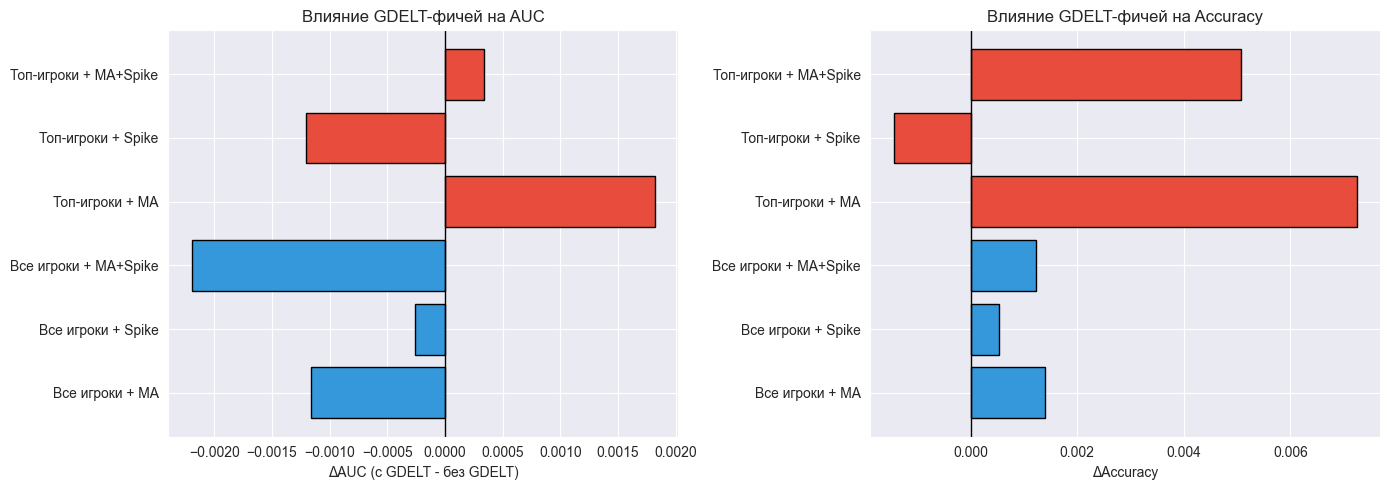

In [6]:
# Сравнительный барплот ΔAUC
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ΔAUC
colors = ['#3498db' if 'Все' in r['label'] else '#e74c3c' for _, r in results_df.iterrows()]
axes[0].barh(results_df['label'], results_df['d_auc'], color=colors, edgecolor='black')
axes[0].axvline(0, color='black', lw=1)
axes[0].set_xlabel('ΔAUC (с GDELT - без GDELT)')
axes[0].set_title('Влияние GDELT-фичей на AUC')

# ΔAccuracy
axes[1].barh(results_df['label'], results_df['d_acc'], color=colors, edgecolor='black')
axes[1].axvline(0, color='black', lw=1)
axes[1].set_xlabel('ΔAccuracy')
axes[1].set_title('Влияние GDELT-фичей на Accuracy')
plt.tight_layout()
plt.show()

## Feature Importance: какие GDELT-фичи наиболее важны?

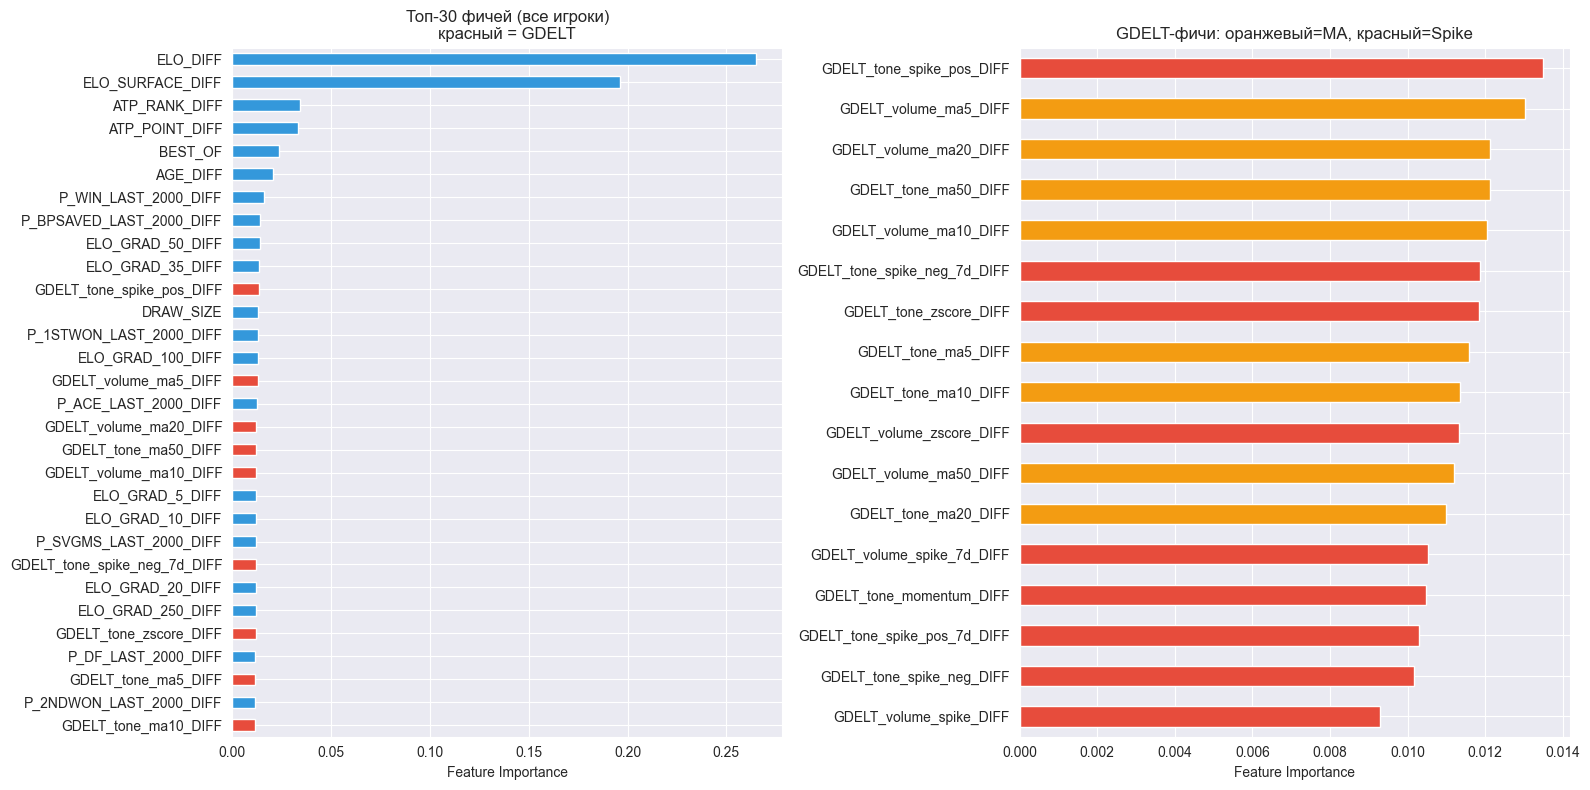


GDELT importance — Топ-игроки:
  📊 GDELT_volume_ma10_DIFF: 0.0200
  ⚡ GDELT_tone_spike_pos_DIFF: 0.0199
  📊 GDELT_volume_ma5_DIFF: 0.0189
  📊 GDELT_tone_ma50_DIFF: 0.0188
  ⚡ GDELT_tone_momentum_DIFF: 0.0187
  📊 GDELT_volume_ma20_DIFF: 0.0185
  ⚡ GDELT_tone_spike_neg_7d_DIFF: 0.0179
  📊 GDELT_tone_ma10_DIFF: 0.0177
  📊 GDELT_tone_ma5_DIFF: 0.0172
  📊 GDELT_tone_ma20_DIFF: 0.0170


In [7]:
# Feature importance для модели на всех данных
all_feat_names = base_features + all_gdelt_cols
importances_all = pd.Series(model_all.feature_importances_, index=all_feat_names).sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(16, 8))

# Топ-30 фичей общая модель
top30 = importances_all.head(30)
colors = ['#e74c3c' if 'GDELT' in f else '#3498db' for f in top30.index]
top30.plot(kind='barh', ax=axes[0], color=colors)
axes[0].set_xlabel('Feature Importance')
axes[0].set_title('Топ-30 фичей (все игроки)\nкрасный = GDELT')
axes[0].invert_yaxis()

# Только GDELT-фичи: MA vs Spike
gdelt_imp = importances_all[importances_all.index.isin(all_gdelt_cols)].sort_values(ascending=False)
colors_gdelt = ['#e74c3c' if any(x in f for x in ['spike', 'zscore', 'momentum']) else '#f39c12' for f in gdelt_imp.index]
gdelt_imp.plot(kind='barh', ax=axes[1], color=colors_gdelt)
axes[1].set_xlabel('Feature Importance')
axes[1].set_title('GDELT-фичи: оранжевый=MA, красный=Spike')
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

# Если есть модель для топ-игроков
if model_top is not None:
    importances_top = pd.Series(model_top.feature_importances_, index=all_feat_names).sort_values(ascending=False)
    gdelt_imp_top = importances_top[importances_top.index.isin(all_gdelt_cols)].sort_values(ascending=False)
    
    print("\nGDELT importance — Топ-игроки:")
    for feat, imp in gdelt_imp_top.head(10).items():
        marker = "⚡" if any(x in feat for x in ['spike', 'zscore', 'momentum']) else "📊"
        print(f"  {marker} {feat}: {imp:.4f}")

## Статистическая значимость: Permutation Test\n\nПроверяем, является ли разница AUC статистически значимой с помощью перемешивания GDELT-фичей.

Permutation Importance GDELT-фичей (на AUC):
                     feature  importance_mean  importance_std
         GDELT_tone_ma5_DIFF         0.000987        0.000397
        GDELT_tone_ma50_DIFF         0.000433        0.000565
      GDELT_volume_ma10_DIFF         0.000315        0.000510
       GDELT_volume_ma5_DIFF         0.000238        0.000402
    GDELT_volume_zscore_DIFF         0.000208        0.000249
    GDELT_tone_momentum_DIFF         0.000187        0.000254
  GDELT_volume_spike_7d_DIFF         0.000142        0.000323
   GDELT_tone_spike_neg_DIFF         0.000015        0.000085
   GDELT_tone_spike_pos_DIFF         0.000015        0.000026
     GDELT_volume_spike_DIFF        -0.000108        0.000081
        GDELT_tone_ma10_DIFF        -0.000148        0.000261
GDELT_tone_spike_neg_7d_DIFF        -0.000170        0.000116
      GDELT_tone_zscore_DIFF        -0.000219        0.000220
        GDELT_tone_ma20_DIFF        -0.000220        0.000395
      GDELT_volume_ma20_D

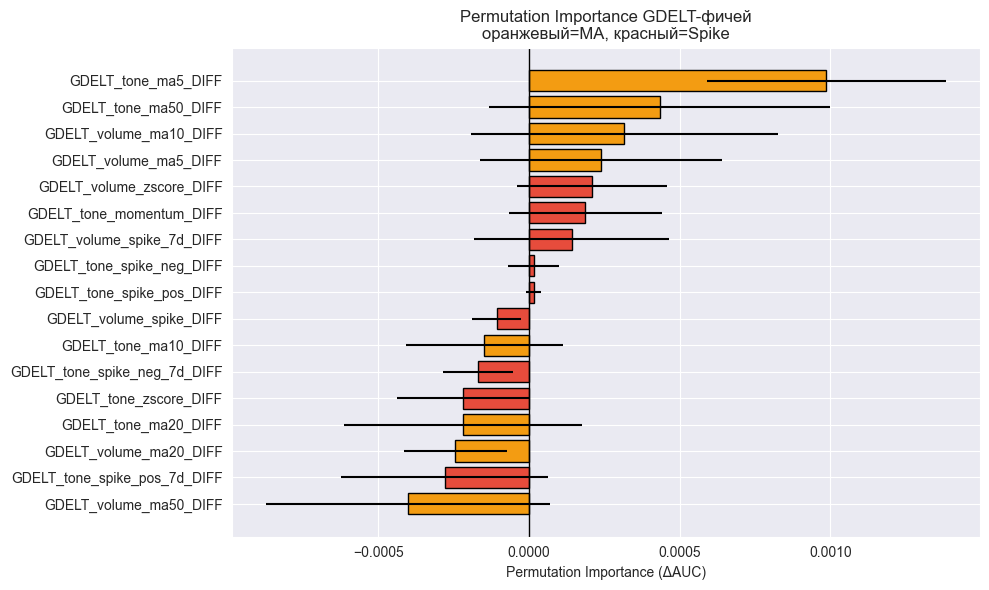

In [8]:
from sklearn.inspection import permutation_importance

# Permutation importance для GDELT-фичей на тестовой выборке (все игроки)
test_all = df[df['tourney_date'] >= split_date]
X_test_full = test_all[base_features + all_gdelt_cols].fillna(0)
y_test_full = test_all['RESULT']

perm_imp = permutation_importance(
    model_all, X_test_full, y_test_full,
    n_repeats=10, random_state=42, scoring='roc_auc'
)

perm_df = pd.DataFrame({
    'feature': base_features + all_gdelt_cols,
    'importance_mean': perm_imp.importances_mean,
    'importance_std': perm_imp.importances_std,
}).sort_values('importance_mean', ascending=False)

# GDELT-фичи
gdelt_perm = perm_df[perm_df['feature'].str.startswith('GDELT_')]
print("Permutation Importance GDELT-фичей (на AUC):")
print(gdelt_perm.to_string(index=False))

# Визуализация
fig, ax = plt.subplots(figsize=(10, 6))
gdelt_perm_sorted = gdelt_perm.sort_values('importance_mean', ascending=True)
colors = ['#e74c3c' if any(x in f for x in ['spike', 'zscore', 'momentum']) else '#f39c12' 
          for f in gdelt_perm_sorted['feature']]
ax.barh(gdelt_perm_sorted['feature'], gdelt_perm_sorted['importance_mean'], 
        xerr=gdelt_perm_sorted['importance_std'], color=colors, edgecolor='black')
ax.axvline(0, color='black', lw=1)
ax.set_xlabel('Permutation Importance (ΔAUC)')
ax.set_title('Permutation Importance GDELT-фичей\nоранжевый=MA, красный=Spike')
plt.tight_layout()
plt.show()

## Выводы

In [9]:
print("=" * 70)
print("ИТОГОВЫЕ РЕЗУЛЬТАТЫ")
print("=" * 70)

print("\n1. ВЛИЯНИЕ GDELT НА КАЧЕСТВО МОДЕЛИ (ΔAUC):")
for _, r in results_df.iterrows():
    sign = "+" if r['d_auc'] >= 0 else ""
    print(f"   {r['label']:<30} ΔAUC = {sign}{r['d_auc']:.4f}")

print(f"\n2. ТОП-ИГРОКИ:")
print(f"   Матчей с топ-игроками (тест): {len(df_top[df_top['tourney_date'] >= split_date])}")
print(f"   Всего матчей (тест): {len(df[df['tourney_date'] >= split_date])}")

best = results_df.loc[results_df['d_auc'].idxmax()]
print(f"\n3. ЛУЧШИЙ РЕЗУЛЬТАТ: {best['label']} (ΔAUC = {best['d_auc']:+.4f})")

if abs(best['d_auc']) < 0.005:
    print("\n   ВЫВОД: GDELT-сентимент НЕ является значимым предиктором")
    print("   результатов теннисных матчей — ни MA, ни spike-фичи,")
    print("   ни фильтрация по топ-игрокам не дают значимого прироста AUC.")
else:
    print(f"\n   ВЫВОД: Обнаружен значимый эффект GDELT ({best['label']})")
    print(f"   ΔAUC = {best['d_auc']:+.4f}")

ИТОГОВЫЕ РЕЗУЛЬТАТЫ

1. ВЛИЯНИЕ GDELT НА КАЧЕСТВО МОДЕЛИ (ΔAUC):
   Все игроки + MA                ΔAUC = -0.0012
   Все игроки + Spike             ΔAUC = -0.0003
   Все игроки + MA+Spike          ΔAUC = -0.0022
   Топ-игроки + MA                ΔAUC = +0.0018
   Топ-игроки + Spike             ΔAUC = -0.0012
   Топ-игроки + MA+Spike          ΔAUC = +0.0003

2. ТОП-ИГРОКИ:
   Матчей с топ-игроками (тест): 2759
   Всего матчей (тест): 5747

3. ЛУЧШИЙ РЕЗУЛЬТАТ: Топ-игроки + MA (ΔAUC = +0.0018)

   ВЫВОД: GDELT-сентимент НЕ является значимым предиктором
   результатов теннисных матчей — ни MA, ни spike-фичи,
   ни фильтрация по топ-игрокам не дают значимого прироста AUC.
